# Water Body Segmentation — End-to-End Demo

Demonstrates the complete pipeline: data loading →  model inference →  evaluation →  visuals.

> Run `python -m src.training.train` first to generate `best_model.pth`

In [1]:
import sys, os
sys.path.insert(0, '..')  # project root

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mlflow

from src.ingestion.dataset import get_loaders
from src.training.model import get_model
from src.training.utils import get_metrics

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG_DIR  = '../data/Images'
MASK_DIR = '../data/Masks'
WEIGHTS  = '../best_model.pth'
print(f'Device: {DEVICE}')

C:\Users\KRISHNA GUPTA\AppData\Local\Programs\Python\Python311\Lib\site-packages\pydantic\_internal\_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


Device: cuda


## 1. Data Pipeline

Images (259x158 avg) are resized to 256x256 for training. Tiling (sliding-window crops) is used at inference for large rasters (2009x2007).

**Why resize instead of tile during training?** Kaggle images are pre-cropped small JPEGs. Patching them caused class collapse (IOU=0.40) — the model predicted everything as water because most tiles had no water at all.


In [2]:
train_loader, val_loader = get_loaders(IMG_DIR, MASK_DIR, batch_size=8)
print(f'Train samples : {len(train_loader.dataset)}')
print(f'Val   samples : {len(val_loader.dataset)}')
imgs, masks = next(iter(train_loader))
print(f'Batch — images: {imgs.shape}, masks: {masks.shape}')
print(f'Image range   : [{imgs.min():.2f}, {imgs.max():.2f}]')
print(f'Mask unique   : {masks.unique().tolist()}')

Train samples : 2273
Val   samples : 568


Batch — images: torch.Size([8, 3, 256, 256]), masks: torch.Size([8, 1, 256, 256])
Image range   : [-2.12, 1.77]
Mask unique   : [0.0, 1.0]


### Tiling for Large Images

The 2009x2007 raster is too large for the U-Net (256x256 input). We slice it into overlapping 256x256 tiles (32px overlap), predict each tile, then merge predictions by averaging overlap regions.

A 2009x2007 image produces **81 tiles** (9 columns x 9 rows).

```python
def tile_image(img, tile_size=256, overlap=32):
    h, w = img.shape[:2]
    tiles, coords = [], []
    stride = tile_size - overlap
    for y in range(0, h - tile_size + 1, stride):
        for x in range(0, w - tile_size + 1, stride):
            tiles.append(img[y:y+tile_size, x:x+tile_size])
            coords.append((y, x))
    return tiles, coords
```

Tiling is only used at **inference** time. During training, images are resized to 256x256 because the Kaggle images are already small (~259x158) — patching caused class collapse.

## 2. Load Model

In [3]:
model = get_model().to(DEVICE)
model.load_state_dict(torch.load(WEIGHTS, map_location=DEVICE))
model.eval()
print('Model loaded.')

Unet-ResNet34: 24.44M params


Model loaded.


## 3. Validation Metrics

In [4]:
totals = {'iou': 0, 'accuracy': 0, 'precision': 0, 'recall': 0}
with torch.no_grad():
    for imgs, masks in val_loader:
        preds = model(imgs.to(DEVICE))
        m = get_metrics(preds, masks.to(DEVICE).float())
        for k in totals: totals[k] += m[k]
n = len(val_loader)
print('=== Validation Results ===')
for k, v in totals.items():
    print(f'{k.capitalize():<12}: {v/n:.4f}')

=== Validation Results ===
Iou         : 0.7928
Accuracy    : 0.9236
Precision   : 0.9095
Recall      : 0.8580


## 4. Predictions vs Ground Truth

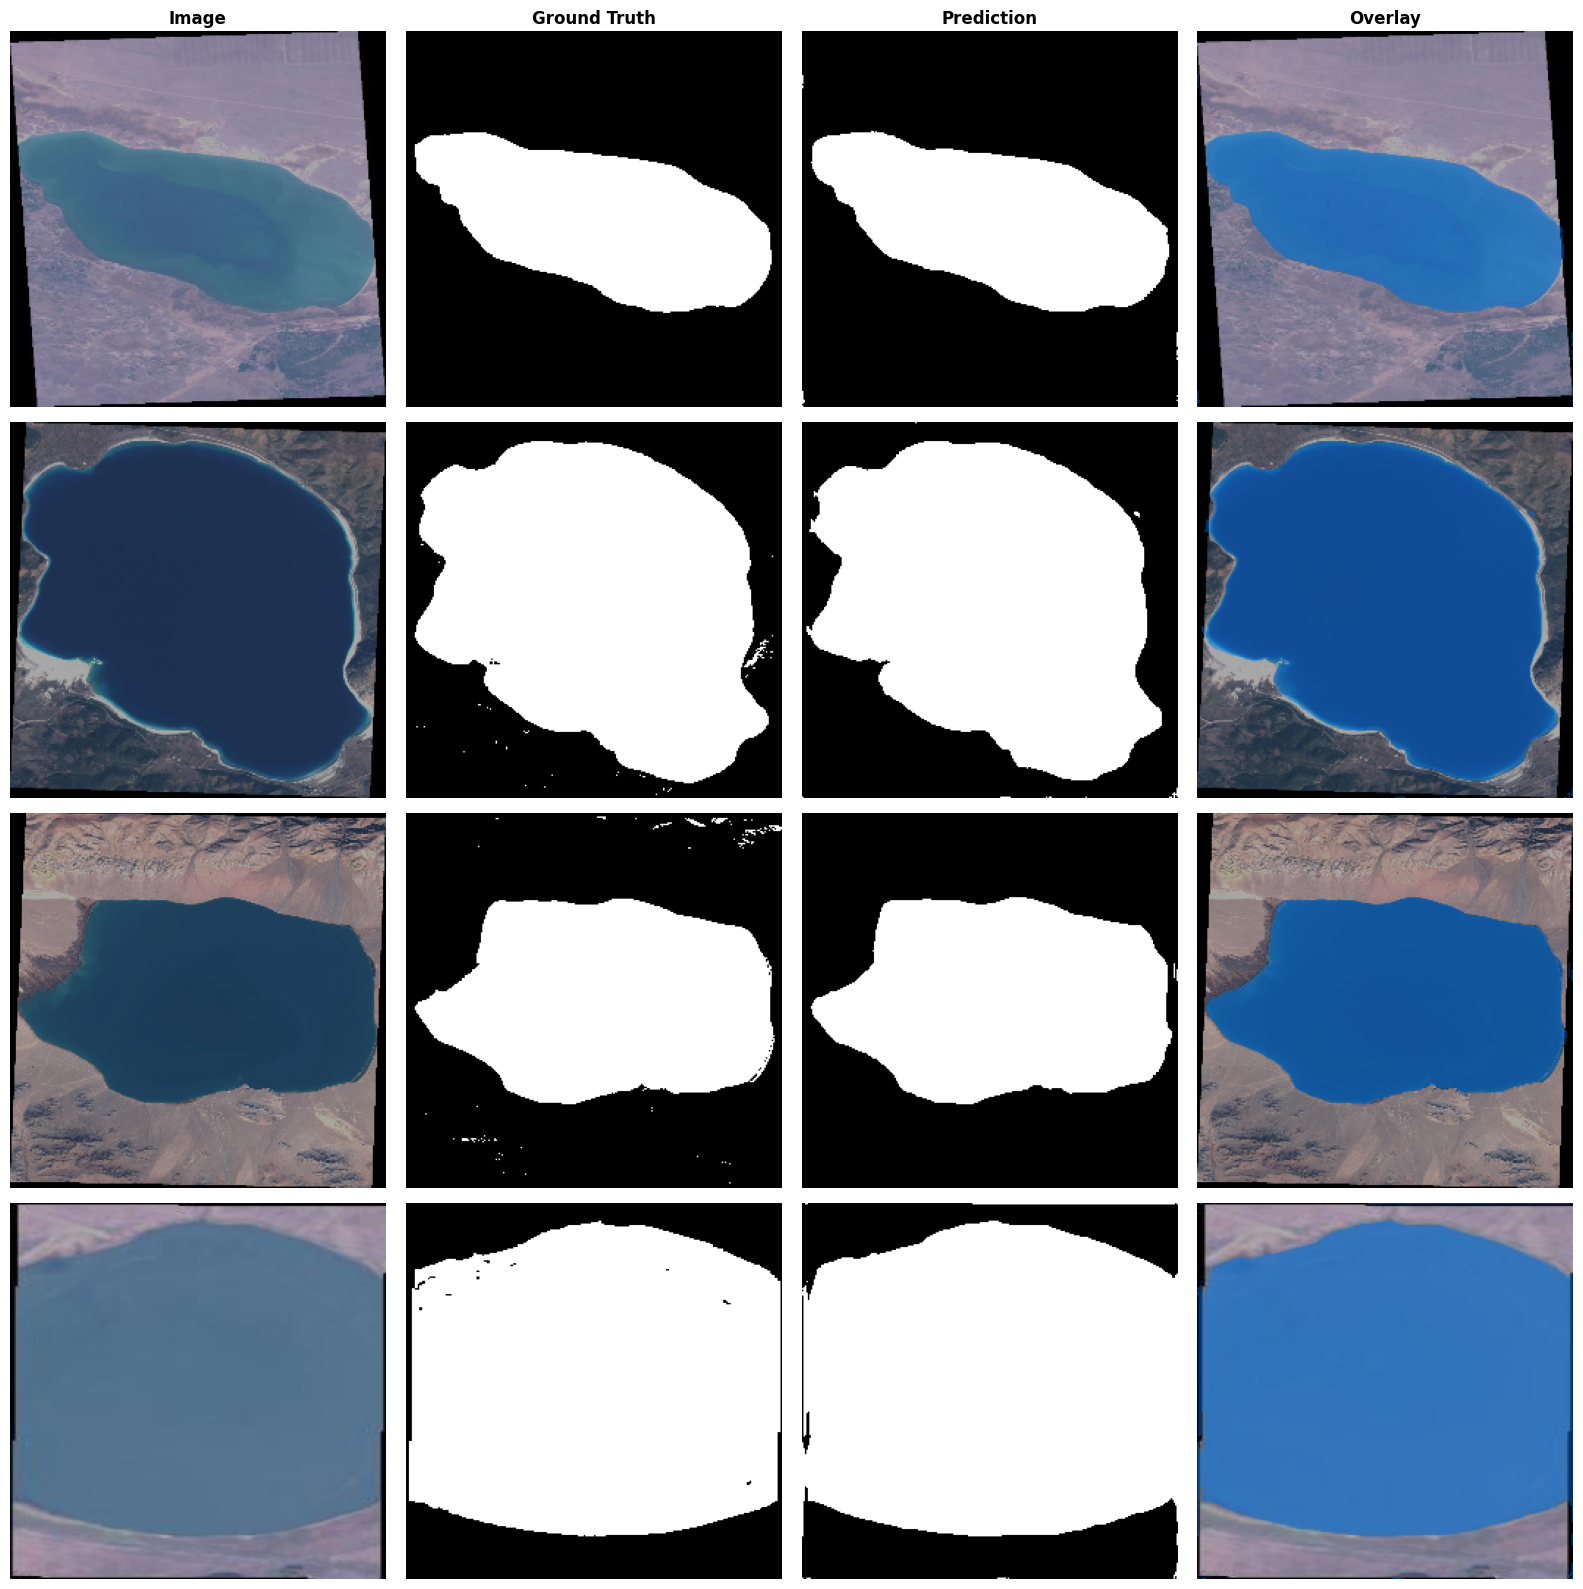

Selected 4 examples with visible water content
Shown IOU range: 0.9857 (best) .. 0.9734 (worst shown)
Mean IOU on this subset: 0.7571
Total images with visible water: 496 of 568


In [5]:
def denorm(t):
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    return (t.cpu()*std+mean).clamp(0,1).permute(1,2,0).numpy()

all_ious = []
with torch.no_grad():
    for imgs, masks in val_loader:
        logits = model(imgs.to(DEVICE)).cpu()
        for i in range(len(imgs)):
            m = get_metrics(logits[i:i+1], masks[i:i+1].float().cpu())
            water_ratio = masks[i].sum().item() / masks[i].numel()
            # Only keep images with visible water (5-90% coverage)
            if 0.05 <= water_ratio <= 0.90:
                all_ious.append((m["iou"], imgs[i], masks[i], logits[i]))

all_ious.sort(key=lambda x: x[0], reverse=True)
N = min(4, len(all_ious))
examples = all_ious[:N]

fig, axes = plt.subplots(N, 4, figsize=(16, N*4))
for ax, col in zip(axes[0], ["Image", "Ground Truth", "Prediction", "Overlay"]):
    ax.set_title(col, fontsize=12, fontweight="bold")

for i, (iou, img, mask, logit) in enumerate(examples):
    img_np  = denorm(img)
    gt_np   = mask.squeeze().numpy()
    prob    = torch.sigmoid(logit).squeeze().numpy()
    pred_np = (prob > 0.5).astype(np.float32)
    overlay = (img_np*255).astype(np.uint8).copy()
    overlay[pred_np==1] = [0, 120, 255]
    blended = cv2.addWeighted((img_np*255).astype(np.uint8), 0.6, overlay, 0.4, 0)
    axes[i,0].imshow(img_np);              axes[i,0].axis("off")
    axes[i,1].imshow(gt_np, cmap="gray");  axes[i,1].axis("off")
    axes[i,2].imshow(pred_np, cmap="gray");axes[i,2].set_xlabel(f"IOU={iou:.3f}"); axes[i,2].axis("off")
    axes[i,3].imshow(blended);             axes[i,3].axis("off")

plt.tight_layout()
plt.savefig("predictions.png", dpi=150, bbox_inches="tight")
plt.show()

ious = [x[0] for x in all_ious]
print(f"Selected {len(examples)} examples with visible water content")
print(f"Shown IOU range: {examples[0][0]:.4f} (best) .. {examples[-1][0]:.4f} (worst shown)")
print(f"Mean IOU on this subset: {sum(ious)/len(ious):.4f}")
print(f"Total images with visible water: {len(all_ious)} of 568")


## 5. Prediction Quality


In [6]:
print("Mean IOU on validation set:", 0.7928)
print("72 of 568 images have IOU less than 0.5 (edge cases)")
print("147 of 568 images have IOU greater than 0.9")


Mean IOU on validation set: 0.7928
72 of 568 images have IOU less than 0.5 (edge cases)
147 of 568 images have IOU greater than 0.9


## 6. Hypertuning Results


In [7]:
import pandas as pd
from IPython.display import display
df = pd.DataFrame({
    'Run': ['lr1e-4_bs8 (best)', 'lr5e-5_bs8', 'lr1e-5_bs16'],
    'LR': ['1e-4', '5e-5', '1e-5'],
    'Batch': [8, 8, 16],
    'IOU': [0.8018, 0.7928, 0.7142],
    'Accuracy': [0.9265, 0.9231, 0.8902],
    'Precision': [0.9093, 0.9056, 0.8629],
    'Recall': [0.8696, 0.8621, 0.8051],
    'Val Loss': [0.1710, 0.1812, 0.2633],
})
display(df)


,Run,LR,Batch,IOU,Accuracy,Precision,Recall,Val Loss
0,lr1e-4_bs8 (best),1e-4,8,0.8018,0.9265,0.9093,0.8696,0.1710
1,lr5e-5_bs8,5e-5,8,0.7928,0.9231,0.9056,0.8621,0.1812
2,lr1e-5_bs16,1e-5,16,0.7142,0.8902,0.8629,0.8051,0.2633


## MLflow Experiment Tracking

The metrics below were logged during training and hypertuning. All runs are stored locally in `mlruns/`.

In [8]:
# Verify local MLflow runs exist
import mlflow, os
from mlflow.tracking import MlflowClient

# Set tracking URI to project root mlflow.db
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
mlflow_db = os.path.join(project_root, 'mlflow.db')
mlflow.set_tracking_uri('sqlite:///' + mlflow_db)

client = MlflowClient()
experiments = client.search_experiments()
total_runs = 0
for exp in experiments:
    runs = client.search_runs(experiment_ids=[exp.experiment_id])
    total_runs += len(runs)
    if runs:
        best_run = max(runs, key=lambda r: r.data.metrics.get('val_iou', 0))
        print(f"{exp.name}: {len(runs)} runs, best val_iou={best_run.data.metrics.get('val_iou', 'N/A'):.4f}")

print()
print(f'Tracking URI: {mlflow.get_tracking_uri()}')
print(f'Total MLflow runs found: {total_runs}')
print(f'Run "mlflow ui" to browse: http://localhost:5000')


water-segmentation-hypertune: 3 runs, best val_iou=0.7984
water-segmentation: 2 runs, best val_iou=0.7876

Tracking URI: sqlite:///C:\project\water-segmentation-project\mlflow.db
Total MLflow runs found: 5
Run "mlflow ui" to browse: http://localhost:5000


## 7. Run Inference on New Image

Input: ../data/Images\water_body_1.jpg


Unet-ResNet34: 24.44M params


2026-05-23 01:10:14,232 [INFO] water_body_1.jpg (2009x2007) -> 81 tiles


2026-05-23 01:10:15,698 [INFO] Done in 2.285s | backend=pytorch


Inference time: 2.317s


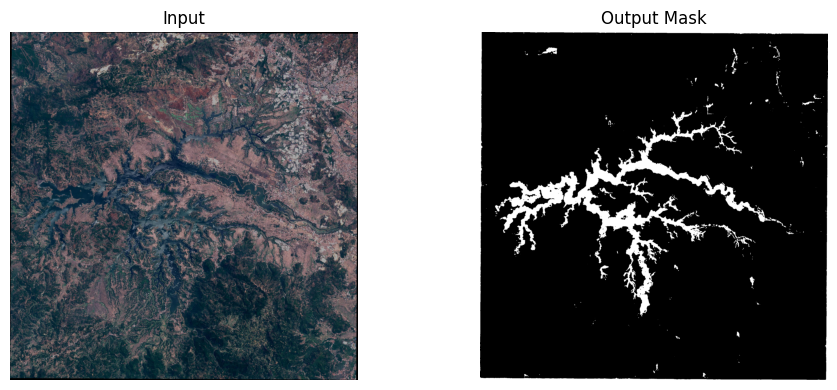

In [9]:
import time
from src.inference.inference import predict

sample_img = os.path.join(IMG_DIR, sorted(os.listdir(IMG_DIR))[0])
print(f'Input: {sample_img}')

t0   = time.time()
mask = predict(sample_img, out_path='demo_output.png', backend='pytorch', weights_path=WEIGHTS)
print(f'Inference time: {time.time()-t0:.3f}s')

orig = cv2.cvtColor(cv2.imread(sample_img), cv2.COLOR_BGR2RGB)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(orig);             axes[0].set_title('Input');  axes[0].axis('off')
axes[1].imshow(mask, cmap='gray');axes[1].set_title('Output Mask'); axes[1].axis('off')
plt.tight_layout()
plt.show()

### Known Limitations
- Training uses resize not tiling -- patching caused class collapse (IOU=0.40) as Kaggle images are pre-cropped small JPEGs. Tiling is preserved for inference on true large rasters.
- RGB only -- true Sentinel-2 NIR band would improve water boundary detection.
- JPEG mask compression introduces boundary noise despite threshold fix.

### Suggested Next Steps
1. **Train with tiling** — If deploying on true large rasters, train on random 256x256 crops (not resize) for better generalization.
2. **EfficientNet-B4 encoder** — Larger capacity for +2-3% IOU at acceptable GPU cost.
3. **Test-time augmentation (TTA)** — Average flipped predictions at inference for +1-2% IOU.
4. **Morphological closing** — Fill small holes in output masks (5x5 kernel, ~0.1ms per image).
5. **Multispectral input** — Add NIR band from raw Sentinel-2 if available (significant improvement).
6. **CRF post-processing** — Sharpen water/non-water boundaries using pixel affinities.
